In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
import torch
import torch.nn as nn

PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

from model.transformer_class import RNABaselineModel, RNATransformer
from model.utils import masked_mse_loss, center_coords, pairwise_distance_loss
from model.dataset_loader import RNADataset, RNATestDataset, rna_collate_fn, rna_test_collate_fn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import plotly.graph_objects as go

plt.style.use("default")
plt.rcParams["figure.figsize"] = (15,6)
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'

# Loading data

In [3]:
train_sequence = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/train_sequences.csv"
)
train_labels = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/train_labels.csv"
)
validation_sequence = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/validation_sequences.csv"
)
validation_labels = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/validation_labels.csv"
)

test_sequence = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/test_sequences.csv"
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18728\3573841072.py:4: DtypeWarning: Columns (0: chain) have mixed types. Specify dtype option on import or set low_memory=False.
  train_labels = pd.read_csv(


In [4]:
train_sequence["len_sequence"] = train_sequence["sequence"].str.len()

In [5]:
train_sequence.head()

,target_id,sequence,temporal_cutoff,description,stoichiometry,all_sequences,ligand_ids,ligand_SMILES,len_sequence
0,4TNA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1978-04-12,FURTHER REFINEMENT OF THE STRUCTURE OF YEAST T...,A:1,>4TNA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2],76
1,6TNA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1979-01-16,CRYSTAL STRUCTURE OF YEAST PHENYLALANINE T-RNA...,A:1,>6TNA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2],76
2,1TRA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1986-07-14,RESTRAINED REFINEMENT OF THE MONOCLINIC FORM O...,A:1,>1TRA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2],76
3,1TN2,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1986-10-24,CRYSTALLOGRAPHIC AND BIOCHEMICAL INVESTIGATION...,A:1,>1TN2_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG;PB;SPM,[Mg+2];[Pb+2];C(CCNCCCN)CNCCCN,76
4,1TN1,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1987-01-15,CRYSTALLOGRAPHIC AND BIOCHEMICAL INVESTIGATION...,A:1,>1TN1_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG;PB;SPM,[Mg+2];[Pb+2];C(CCNCCCN)CNCCCN,76


In [6]:
train_labels.head()

,ID,resname,resid,x_1,y_1,z_1,chain,copy
0,157D_1,C,1,4.843,-5.640,13.265,A,1
1,157D_2,G,2,3.385,-7.613,8.267,A,1
2,157D_3,C,3,2.158,-6.751,2.949,A,1
3,157D_4,G,4,2.669,-4.843,-1.773,A,1
4,157D_5,A,5,3.509,0.239,-4.045,A,1


In [7]:
print("number of unique target IDs which are pdb_id_chain_id", train_sequence["target_id"].nunique())

number of unique target IDs which are pdb_id_chain_id 5716


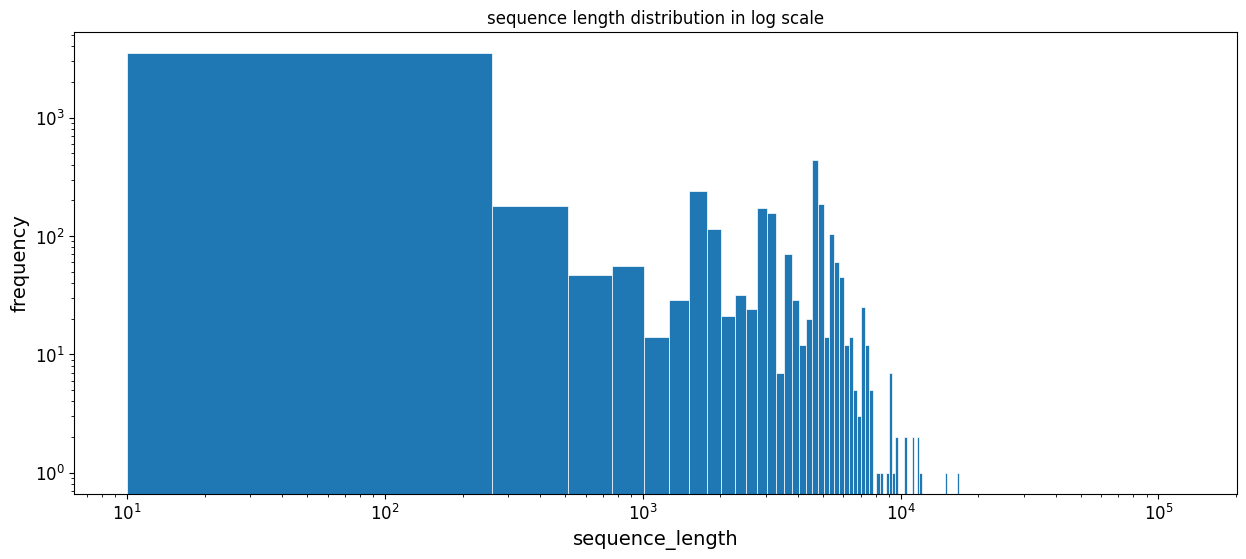

In [8]:
# distribution of sequence lengths:


fig, ax = plt.subplots()

ax.hist(train_sequence["len_sequence"], bins=500, linewidth=0.5, edgecolor="white")
ax.set_yscale('log', base=10)
ax.set_xscale('log', base=10)
plt.xlabel("sequence_length")
plt.ylabel("frequency")
plt.title("sequence length distribution in log scale")
plt.show()


In [9]:
train_labels[["split_ID", "suffix"]] = train_labels["ID"].str.split('_', expand=True)

In [58]:
# plotting some target examples
unique_ids = train_labels["split_ID"].unique()
for target_id in unique_ids[:10]:
    # target_id = train_labels["ID"].iloc[i].split("_")[0]
    sub = train_labels[train_labels["ID"].str.startswith(target_id)]

    x = sub["x_1"].values
    y = sub["y_1"].values
    z = sub["z_1"].values


    fig = go.Figure(
        data=[go.Scatter3d(
            x=x, y=y, z=z,
            mode="lines+markers",
            marker=dict(size=3),
            line=dict(width=2)
        )]
    )

    fig.update_layout(
        title=f"RNA structure: {target_id}",
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z"
        )
    )

    fig.show()



In [11]:

lengths = train_sequence["sequence"].str.len()

print("sequence length percentiles:", np.percentile(lengths, [50, 75, 90, 95, 99]))

sequence length percentiles: [  94.5  2583.75 4751.   5348.   7230.6 ]


In [12]:
# Reducing long sequences examples for initial model run

# filtered_train_sequence = train_sequence[train_sequence["sequence"].str.len() <2500]

valid_targets = set(
    train_sequence.loc[train_sequence.len_sequence < 2000, "target_id"]
)

train_sequences = train_sequence[
    train_sequence.target_id.isin(valid_targets)
]

train_labels = train_labels[
    train_labels.split_ID.isin(valid_targets)
]

In [13]:
from torch.utils.data import DataLoader

dataset = RNADataset(train_sequences, train_labels)

# Checking correct dataset creation: sequence should be of shape (L,), and each nucleotide should have 3 coordinates, which makes shape (L,3)
seq, coords = dataset[0]

print(seq.shape)     # (L,)
print(coords.shape)  # (L, 3)

torch.Size([76])
torch.Size([76, 3])


In [14]:
dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=rna_collate_fn
)

# Modeling

In [15]:
# model = RNABaselineModel()
# optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)

In [16]:
# batch = next(iter(dataloader))

# tokens = batch["tokens"]
# coords = batch["coords"]
# mask = batch["mask"]

# print(tokens.shape)
# print(coords.shape)
# print(mask.shape)

# pred = model(tokens)
# loss = masked_mse_loss(pred, coords, mask)

# loss.backward()
# optimizer.step()
# optimizer.zero_grad()

# print("Loss:", loss.item())


In [17]:
# model.train()
# loss_vs = []
# for step, batch in enumerate(dataloader):
#     tokens = batch["tokens"]
#     coords = batch["coords"]
#     mask = batch["mask"]

#     pred = model(tokens)

#     coords_centered = center_coords(coords, mask)
#     pred_centered   = center_coords(pred, mask)

#     loss = masked_mse_loss(pred_centered, coords_centered, mask)
#     loss_vs.append(loss.item())

#     loss.backward()
#     optimizer.step()
#     optimizer.zero_grad()

#     if step % 10 == 0:
#         print(f"Step {step} | Loss {loss.item():.2f}")

#     if step == 500:
#         break


In [18]:
# plt.plot(loss_vs)
# plt.xlabel("epoch")
# plt.ylabel("masked mse loss")
# plt.title("Baseline Model training loss curve")
# plt.show()

In [19]:
# from torch.utils.data import DataLoader

# test_dataset = RNATestDataset(test_sequence)

# test_loader = DataLoader(
#     test_dataset,
#     batch_size=1,          # IMPORTANT for submission simplicity
#     shuffle=False,
#     collate_fn=rna_test_collate_fn
# )

In [20]:
# # shapes
# batch = next(iter(test_loader))

# print(batch["tokens"].shape)   # (1, L)
# print(batch["mask"].shape)     # (1, L)
# print(batch["meta"])

# Naive Inference 

In [21]:
# model.eval()

# all_predictions = []

# with torch.no_grad():
#     # disables dropout (if any)
#     # disables gradient tracking
#     # saves memory

#     for batch in test_loader:
#         tokens = batch["tokens"]       # (1, L)
#         mask = batch["mask"]           # (1, L)
#         meta = batch["meta"][0]        # dict

#         pred = model(tokens)           # (1, L, 3)
#         pred = pred.squeeze(0)         # (L, 3)

#         L = meta["length"]

#         all_predictions.append({
#             "target_id": meta["target_id"],
#             "coords": pred[:L].cpu().numpy()  # (L, 3)
#         })

In [22]:
# # Create submission
# submission_rows = []

# for item in all_predictions:
#     target_id = item["target_id"]
#     coords = item["coords"]      # (L, 3)

#     # Get original sequence from test_sequences_df
#     seq = test_sequence.loc[
#         test_sequence["target_id"] == target_id, "sequence"
#     ].values[0]

#     for i, nucleotide in enumerate(seq):
#         row = {
#             "ID": f"{target_id}_{i+1}",
#             "resname": nucleotide,
#             "resid": i + 1,
#         }

#         # repeat same coords for x_1..x_5
#         for k in range(1, 6):
#             row[f"x_{k}"] = float(coords[i, 0])
#             row[f"y_{k}"] = float(coords[i, 1])
#             row[f"z_{k}"] = float(coords[i, 2])

#         submission_rows.append(row)

# submission_df = pd.DataFrame(submission_rows)

# submission_df.to_csv("submission.csv", index=False)

In [23]:
# submission_df

# Encoder Model

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [46]:
model = RNATransformer()
model = model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-2
)

batch = next(iter(dataloader))

tokens = batch["tokens"].to(device)
coords = batch["coords"].to(device)
mask = batch["mask"].to(device)

pred = model(tokens)

print(pred.shape)     # (B, L, 3)
print(coords.shape)   # (B, L, 3)

torch.Size([4, 1533, 3])
torch.Size([4, 1533, 3])


In [51]:
model.train()
mse_loss_list = []
pairwise_d_list = []
loss_vs = []
lambda_distance = 2.0

for step, batch in enumerate(dataloader):
    tokens = batch["tokens"].to(device)
    coords = batch["coords"].to(device)
    mask = batch["mask"].to(device)

    pred = model(tokens)

    coords_centered = center_coords(coords, mask)
    pred_centered   = center_coords(pred, mask)

    mse_loss = masked_mse_loss(pred_centered, coords_centered, mask)
    distance_loss = pairwise_distance_loss(pred_centered, coords_centered, mask)
    
    loss = mse_loss + lambda_distance * distance_loss
    
    mse_loss_list.append(mse_loss.item())
    pairwise_d_list.append(distance_loss.item())
    loss_vs.append(loss.item())

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if step % 10 == 0:
        print(f"Step {step} | Loss {loss.item():.2f}")


Step 0 | Loss 1321.65
Step 10 | Loss 2563.85
Step 20 | Loss 2712.70
Step 30 | Loss 13781.84
Step 40 | Loss 14197.83
Step 50 | Loss 969.94
Step 60 | Loss 5647.15
Step 70 | Loss 6007.37
Step 80 | Loss 549.88
Step 90 | Loss 6195.63
Step 100 | Loss 2038.49
Step 110 | Loss 14898.59
Step 120 | Loss 14973.49
Step 130 | Loss 4768.71
Step 140 | Loss 9042.31
Step 150 | Loss 26753.86
Step 160 | Loss 731.31
Step 170 | Loss 4734.42
Step 180 | Loss 4662.46
Step 190 | Loss 490.85
Step 200 | Loss 1173.51
Step 210 | Loss 11814.64
Step 220 | Loss 57525.84
Step 230 | Loss 1212.72
Step 240 | Loss 21352.99
Step 250 | Loss 23698.05
Step 260 | Loss 1294.32
Step 270 | Loss 2393.58
Step 280 | Loss 13961.84
Step 290 | Loss 3124.54
Step 300 | Loss 5233.36
Step 310 | Loss 705.88
Step 320 | Loss 5668.33
Step 330 | Loss 2681.11
Step 340 | Loss 573.70
Step 350 | Loss 23261.96
Step 360 | Loss 1496.86
Step 370 | Loss 7478.48
Step 380 | Loss 1904.04
Step 390 | Loss 696.83
Step 400 | Loss 1132.33
Step 410 | Loss 1298.05

In [55]:
trend_list = []
tmp = []
for i, v in enumerate(loss_vs):
    tmp.append(v)
    if i%20==0:
        trend_list.append(np.mean(tmp))
        tmp=[]


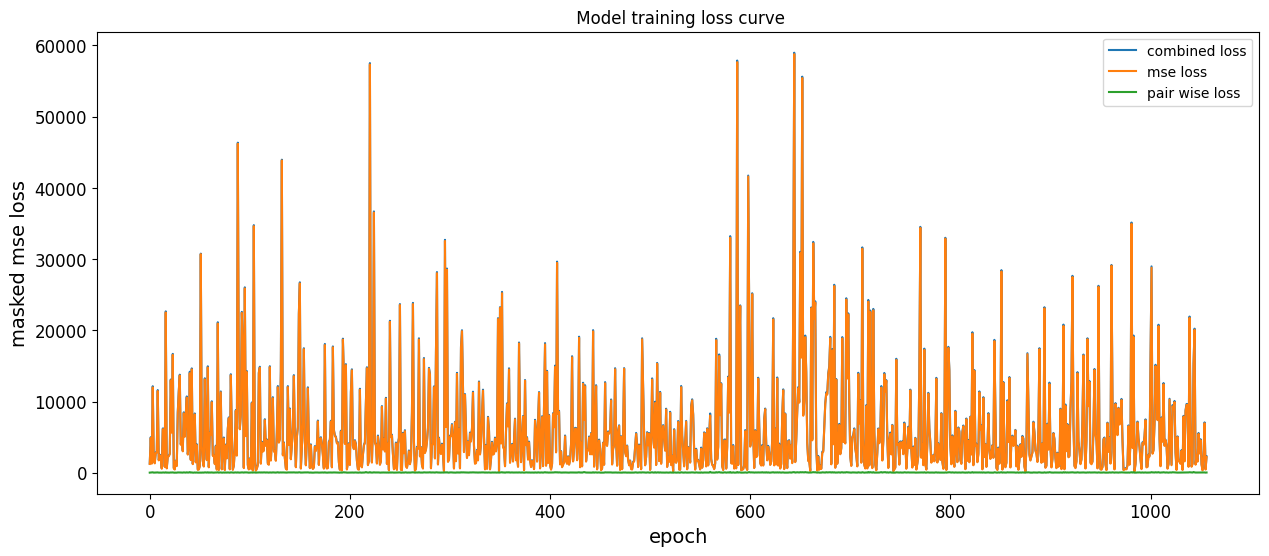

In [53]:
plt.plot(loss_vs, label = "combined loss")
plt.plot(mse_loss_list, label = "mse loss")
plt.plot(pairwise_d_list, label = "pair wise loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("masked mse loss")
plt.title(" Model training loss curve")
plt.show()

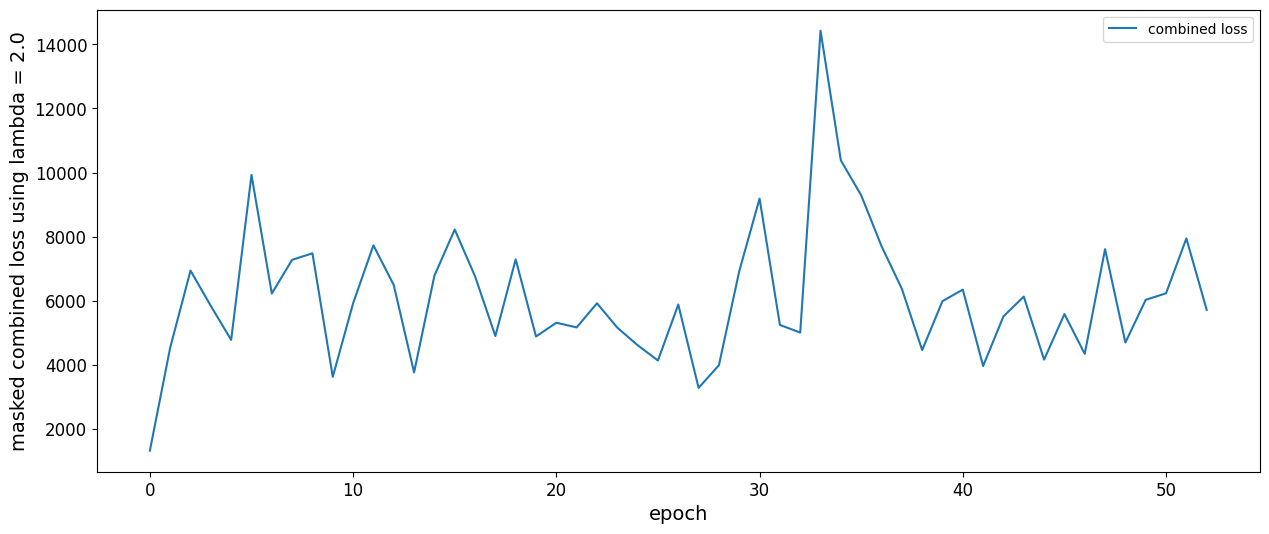

In [56]:
plt.plot(trend_list, label = "combined loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("masked combined loss using lambda = 2.0")
plt.show()

In [28]:
from torch.utils.data import DataLoader

test_dataset = RNATestDataset(test_sequence)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,          # IMPORTANT for submission simplicity
    shuffle=False,
    collate_fn=rna_test_collate_fn
)

In [29]:
model.eval()

all_predictions = []

with torch.no_grad():
    # disables dropout (if any)
    # disables gradient tracking
    # saves memory

    for batch in test_loader:
        tokens = batch["tokens"].to(device)       # (1, L)
        mask = batch["mask"].to(device)          # (1, L)
        meta = batch["meta"][0]        # dict

        pred = model(tokens)           # (1, L, 3)
        pred = pred.squeeze(0)         # (L, 3)

        L = meta["length"]

        all_predictions.append({
            "target_id": meta["target_id"],
            "coords": pred[:L].cpu().numpy()  # (L, 3)
        })

In [30]:
# Create submission
submission_rows = []

for item in all_predictions:
    target_id = item["target_id"]
    coords = item["coords"]      # (L, 3)

    # Get original sequence from test_sequences_df
    seq = test_sequence.loc[
        test_sequence["target_id"] == target_id, "sequence"
    ].values[0]

    for i, nucleotide in enumerate(seq):
        row = {
            "ID": f"{target_id}_{i+1}",
            "resname": nucleotide,
            "resid": i + 1,
        }

        # repeat same coords for x_1..x_5
        for k in range(1, 6):
            row[f"x_{k}"] = float(coords[i, 0])
            row[f"y_{k}"] = float(coords[i, 1])
            row[f"z_{k}"] = float(coords[i, 2])

        submission_rows.append(row)

submission_df = pd.DataFrame(submission_rows)

submission_df.to_csv("submission.csv", index=False)